# 2D dynamical system in 3D

## Setup

### Packages and functions

In [141]:
using LinearAlgebra, GLMakie, NLsolve
using StatsBase: mean, sample, wsample, median
import Random

@isdefined(Dynamical2D) || include("../tools/Dynamical2D.jl")
using .Dynamical2D
using .Dynamical2D: Q, spa, SurfaceFun.sphere

# clipping for visualization
function clip(x,p=[0.01,0.99])
    position(p) = Int.(round.(length(x)*p))
    p = length(p)==1 ? [p,1-p] : p
    lower, upper = position.(p)
    xs = sort(x)
    clamp.(x,xs[lower],xs[upper])
end

clipmax(x;p=0.05) = maximum(abs.(clip(x,p)))

ax3d(f;azymuth=0.4pi,kwargs...) = # 0.7pi or 0.4pi
    Axis3(
        f, viewmode=:fitzoom, aspect=:data, azimuth=azymuth,
        #xlabel=varnames[1], ylabel=varnames[2], zlabel=varnames[3],
        protrusions=(30,0,30,0)
    )

ax3d (generic function with 1 method)

### Makie theme

In [181]:
if false
    # for figure: white BG, vector graphics
    import CairoMakie
    CairoMakie.activate!(type="svg")
    linecolor = :black
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use: dark BG, raster graphics
    using GLMakie
    GLMakie.activate!(px_per_unit=1)
    linecolor = :black
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Model definition

In [154]:
shape = SetShape(:quadric)
#shape = SetShape(:cylinder)
J, G, Dc, divM, curlM = diffOpsM(shape.f) #;drgi=drgi)
rtgi(x,y) = G(x,y)^(-1/2)
U(x,y) = exp(-((x+1/2)^2+(y+1/2)^2)/2) - exp(-((x-1/2)^2+(y-1/2)^2)/2)
#fg(x,y) = [0,0] # gradient part
fg(x,y) = -∇(U)(x,y) # gradient part
#fc(x,y) = -Q*∇(U)(x,y) 
fc(x,y) = 0Q*fg(x,y) # curl part for sphere: J*g^-1*F = du
fp(x,y) = fg(x,y) + fc(x,y) # vector field on parameter space

# Velocity on parameter space for simulation
vfp(x) = G(x...)\fp(x...) # inverse-scaled vector field
# Velocity on tangent plane for observation
vft(x) = J(x...)*vfp(x) # (J √g⁻¹)'(J √g⁻¹) = I

# Vector calculus on M
divRM = divM(fp)
curlRM = curlM(fp)

fps = sort([nlsolve(spa(fp),x).zero for x in [[0.5,0.5],[-0.5,-0.5]]])

2-element Vector{Vector{Float64}}:
 [-0.7717023191948433, -0.7717023191948433]
 [0.7717023191948433, 0.7717023191948433]

## Sampling trajectory

In [155]:
N = 1600
μc = fps[argmin(first.(fps))]
samples = let tmax = 100 #[-1.0,0.5] #[-0.5,-0.5] #fps[argmin(first.(fps))]
    samples = zeros(2,tmax+1,N)
    gbase = rtgi(μc...)
    @time for i in 1:N
        ini = 0.5*gbase*randn(2) + μc
        samples[:,:,i] = kutta(vfp,ini,dt=0.02,s=tmax)
    end
    samples
end

  4.762274 seconds (50.43 M allocations: 1.958 GiB, 10.05% gc time)


2×101×1600 Array{Float64, 3}:
[:, :, 1] =
 -0.86879   -0.867749  -0.866616  …  -0.0232983  -0.0110723  0.00103445
 -0.223023  -0.213771  -0.20438       0.815337    0.819287   0.82306

[:, :, 2] =
 -1.08573   -1.08966   -1.09363   …  -1.54729    -1.55164    -1.55597
 -0.542585  -0.539489  -0.536356     -0.0778326  -0.0720429  -0.0662517

[:, :, 3] =
 -1.42833   -1.43409   -1.43986  …  -1.94128   -1.94561   -1.94993
 -0.854508  -0.855251  -0.85599     -0.897335  -0.897477  -0.897615

;;; … 

[:, :, 1598] =
 -0.29497  -0.290337  -0.28569  -0.281029  …   0.158411   0.162554   0.166682
 -1.47527  -1.48062   -1.48597  -1.4913       -1.89114   -1.89409   -1.89702

[:, :, 1599] =
 -0.73597   -0.734293  -0.732556  -0.730755  …  0.138186  0.150597  0.162798
 -0.508088  -0.503019  -0.497842  -0.492554     0.556118  0.563949  0.571526

[:, :, 1600] =
 -0.406365  -0.402458  -0.39853  …   0.0100369   0.014063   0.0180771
 -1.39016   -1.39574   -1.40133     -1.86652    -1.87017   -1.8738

┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:166
┌ Warning: arrowsize has been deprecated in favor of tipradius and tiplength.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:206
┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:166
┌ Warning: arrowsize has been deprecated in favor of tipradius and tiplength.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:206
┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:166
┌ Warning: arrowsize has been deprecated in favor of tipradius and tiplength.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:206
┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/4JW9

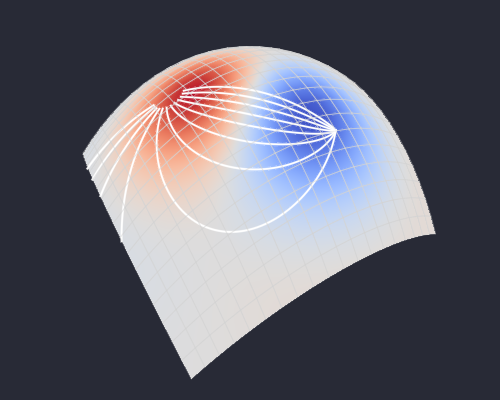

In [156]:
#pts2 = Point2f.(eachcol(samples[:,50,:]))
pts2 = [Point2f(sample(eachcol(samples[:,:,i]))) for i in 1:size(samples,3)] # random time
#pts2 = vec(let xs=LinRange(-2,2,40); ((x,y) -> Point2f(x,y)).(xs',xs);end) # grid

pts2 = vcat(Point2f.(fps),pts2); N=1600+length(fps) # add fixed points 
X = hcat(spa(shape.f).(pts2)...)
pts = Point3f.(eachcol(X))
V = hcat(vft.(pts2)...)
#zshift(p;s=0.01) = p + Point3f(0,0,s)

fig=Figure(size=(500,400))
ax = LScene(fig[1,1],show_axis=false)
rx = 2.1
xs = LinRange(-rx,rx,20)
P = Point3f.(shape.f.(xs,xs'))
#vfun = x -> G(x...)\ff(x...)
#scatter!(ax,pts,markersize=5,color=:lightgrey,transparency=false)
#surface!(ax,xs,xs,last.(P).-0.02,color=U.(xs,xs'),transparency=false,shading=NoShading)
surface!(ax,xs,xs,last.(P).-0.02,color=divRM.(xs,xs'),colormap=:coolwarm,transparency=false,shading=NoShading)
#surface!(ax,xs,xs,last.(P).-0.02,colormap=[RGBf([8,31,92]/255...)],transparency=false,shading=NoShading)
wireframe!(ax,xs,xs,last.(P).-0.01,color=:lightgrey,transparency=true,linewidth=0.5)

#for ϕ in LinRange(-pi,pi,12)[2:end], dir in [-1,1], θ in [0,pi/2]
for ini in [μc+0.2*[cos(θ),sin(θ)] for θ in LinRange(-1.8,1,12)]
    traj = kutta(normalize ∘ vfp,ini,dt=0.05,s=80)
    traj3 = Point3f.(spa(shape.f).(eachcol(traj)))
    oor = findfirst([abs(x)>rx || abs(y)>rx for (x,y,z) in traj3])
    if !isnothing(oor)
        traj3 = traj3[1:oor]
    end
    lines!(ax,traj3,color=:white,transparency=true,linewidth=2)
    ishow = sample(1:length(traj3),2)
    #scatter!(ax,traj3[ishow])
    tvs = Vec3f.(vft.(eachcol(traj[:,ishow])))
    quiver!(    
        ax, traj3[ishow], 0.01tvs,
        arrowsize=0.09, linewidth=0.015, color=:white, #RGBf([8,31,92]/255...),
        shading=NoShading,transparency=true
    )
end

#ishow = sample(1:N,100)
#quiver!(ax,vec(P),vec(0.2*vps),color=:black,fxaa=true,arrowsize=0.06,linewidth=0.015,shading=MultiLightShading,transparency=false)
# quiver!(    
#     ax, pts[ishow], 0.4*Vec3f.(eachcol(V)[ishow]),
#     arrowsize=0.06, linewidth=0.015, color=:white, #RGBf([8,31,92]/255...),
#     shading=NoShading,transparency=true
# )

cam3d!(ax.scene, center=false)
translate!(ax.scene,Vec3f(0,0,2.5))
eyepos = Vec3f(sphere(-30pi/180,60pi/180,r=7.5))
update_cam!(ax.scene, eyepos, Vec3f(0), Vec3f(0,0,1))
fig

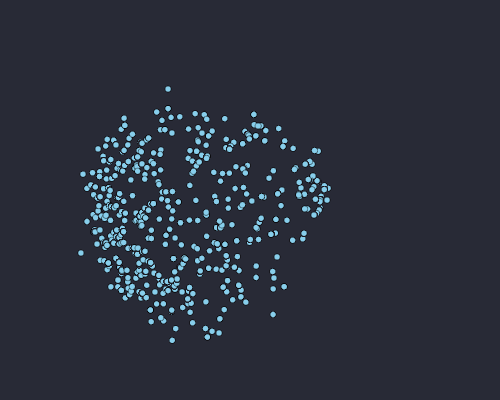

In [157]:
fig=Figure(size=(500,400))
ax = LScene(fig[1,1],show_axis=false)
ishow = sample(1:N,500)
#quiver(pts2[ishow],Vec2f.(eachcol(0.2V[:,ishow])))
#scatter!(ax,pts[ishow],color=RGBf([8,31,92]/255...),markersize=8,strokewidth=0.5,strokecolor=:white)
scatter!(ax,pts[ishow],color=:skyblue,markersize=8,strokewidth=0.5,strokecolor=:black)
cam3d!(ax.scene, center=false)
translate!(ax.scene,Vec3f(0,0,2.5))
eyepos = Vec3f(sphere(-60pi/180,90pi/180,r=7.5))
update_cam!(ax.scene, eyepos, Vec3f(0), Vec3f(0,0,1))
fig

## Embedding

In [158]:
using NearestNeighbors: KDTree, knn
# Epanechnikov quadratic kernel
kernel(t) = 3/4*(1-t^2) # defined for 0<=t<=1
#kernel(t;σ=1) = gauss(t,μ=0,σ=0.5)

# K-nn value
function knnvalue(x;tree,value,k=30,ϵ=0.5)
    i, d = knn(tree, x, k, true)
    (d[1] > ϵ) && return(fill(NaN,length(value[1])))
    v = value[i]
    w = kernel.(d/d[k])
    v'*(w/sum(w))
end

knnvf(x;k=10,ϵ=0.5,vels,tree) = vec(knnvalue(x;tree=tree,value=vels,k=k,ϵ=ϵ))

function stream!(ax,X,V;k=10,ϵ=0.1,opts...)
    d = size(X,1)
    vf = x -> knnvf(x;tree=KDTree(X),vels=eachcol(V),k=k,ϵ=ϵ)
    interval = x -> minimum(1.1x)..maximum(1.1x)
    exts = interval.(eachrow(X))
    streamplot!(
        ax, Point{d,Float32} ∘ vf, exts...;
        colormap=[:black],arrow_size=8,linewidth=1.5,
        gridsize=Tuple(fill(20,d)),
        opts...
    ) 
    #arrow_size=arrow_size,linewidth=1.8,colormap=[(color,0.6)],gridsize=gridsize)
end

# Velocity embedding; according to scvelo method
function vemb(g,Xe,X,V;σ=1.0)
    map(1:nv(g)) do i
        neis = neighbors(g,i)
        # normalized displacement in the embedding space
        D = mapslices(normalize,X[:,neis] .- X[:,i],dims=1)
        De = mapslices(normalize,Xe[:,neis] .- Xe[:,i],dims=1)
        # cosine weights
        wts = exp.(D'*normalize(V[:,i])/σ^2)
        # density correction
        De*(wts/sum(wts) .- 1/length(wts))
    end
end

# Show as directional field
function dirfld!(ax,xs,vs;α=1.0,color=nothing,cmap=:coolwarm,opts...)
    d = size(xs,1)
    xs = Point{d,Float32}.(eachcol(xs))
    vs = α*Vec{d,Float32}.(normalize.(eachcol(vs)))
    cmax = clipmax(color,p=0.99)
    quiver!(
        ax, xs.-0.5vs, vs; rasterize=2,
        color=color, arrowsize=0, linewidth=1,
        colormap=cmap, colorrange=(-cmax,cmax),
        opts...
    )
end

mark12!(ax,X;opts...) = scatter!(
    ax, Point2f.(eachcol(X[1:2,1:2]));
    strokewidth=2, strokecolor=[:salmon,:skyblue],
    markersize=8, color=[:salmon,:skyblue], #:transparent, 
    opts...
)

mark12! (generic function with 1 method)

In [159]:
using ddHodge, Graphs
import UMAP
umodel = UMAP.UMAP_(X,min_dist=0.5,n_epochs=500)
UM = umodel.embedding
divana = spa(divRM).(pts2)
g, kdtree = kNNGraph(X,6)
#import TSne
#Ut = TSne.tsne(X')'

(SimpleGraph{Int64}(5745, [[123, 250, 555, 562, 984, 1275, 1383], [226, 389, 557, 673, 1053, 1545], [168, 347, 761, 900, 1137, 1208, 1564], [100, 339, 353, 662, 759, 1011, 1353], [236, 333, 413, 658, 842, 1122], [284, 458, 843, 844, 1212, 1304, 1372], [139, 605, 799, 869, 890, 1036, 1444], [91, 485, 507, 704, 730, 796, 1354, 1484], [325, 437, 450, 610, 611, 879, 886, 999, 1240], [154, 545, 703, 891, 1169, 1260, 1514]  …  [550, 582, 1124, 1320, 1435, 1534], [33, 47, 94, 213, 370, 1170, 1412, 1580], [548, 557, 673, 1125, 1342, 1503, 1518], [774, 828, 830, 944, 1192, 1558], [371, 406, 488, 640, 768, 968, 978, 1298], [22, 124, 379, 804, 1062, 1403, 1574], [186, 483, 570, 1092, 1171, 1420], [287, 351, 1023, 1354, 1528, 1602], [36, 225, 683, 889, 915, 990, 1097, 1295], [76, 98, 287, 351, 367, 583, 627, 1023, 1528, 1600]]), KDTree{StaticArraysCore.SVector{3, Float64}, Distances.Euclidean, Float64, StaticArraysCore.SVector{3, Float64}}
  Number of points: 1602
  Dimensions: 3
  Metric: Distanc

┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:166
┌ Warning: arrowsize has been deprecated in favor of tipwidth and tiplength.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:206
┌ Warning: `arrows` are deprecated in favor of `arrows2d` and `arrows3d`.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:166
┌ Warning: arrowsize has been deprecated in favor of tipwidth and tiplength.
└ @ Makie ~/.julia/packages/Makie/4JW9B/src/basic_recipes/arrows.jl:206


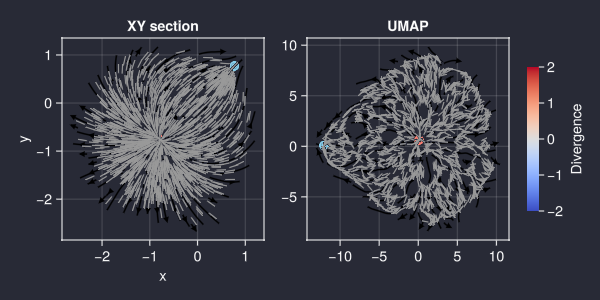

In [160]:
Vu = hcat(vemb(g,UM,X,V,σ=1.0)...)
#Vt = hcat(vemb(g,Ut,X,V,σ=1.0)...)
#Vc = hcat(spa(devcone).(pts2 + vfp.(pts2)) - eachcol(UC)...)

let showstream=true, cmap=:coolwarm #[:grey]
    fig = Figure(size=(600,300))
    ax1 = Axis(fig[1,1],aspect=1,title="XY section",xlabel="x",ylabel="y")
    ax2 = Axis(fig[1,2],aspect=1,title="UMAP")
    dirfld!(ax1,X[1:2,:],V[1:2,:]; α=0.2,color=divana, cmap=[:grey60])
    showstream && stream!(ax1,X[1:2,:],V[1:2,:],ϵ=0.2)#,ϵ=1.0)
    mark12!(ax1,X[1:2,:])
    dirfld!(ax2,UM,Vu;α=0.8,cmap=[:grey60], color=divana)
    showstream && stream!(ax2,UM,Vu,arrow_size=8,ϵ=1.0)#10.0)
    mark12!(ax2,UM)
    Colorbar(fig[1,3],colormap=:coolwarm,colorrange=(-2,2),height=Relative(0.7),label="Divergence")
    fig
end

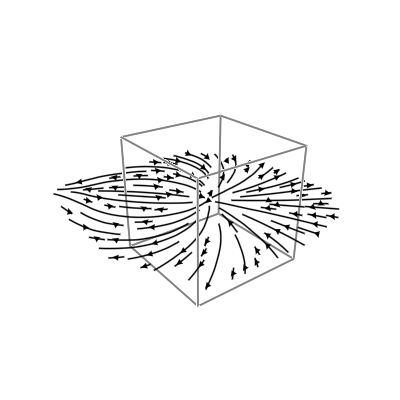

In [176]:
import GLMakie.GeometryBasics as GB

with_theme(theme_light()) do
    mr = Rect3f(Vec3f(-0.5), Vec3f(1))
    mr_n = GB.normal_mesh(mr)
    pl = Rect2f(Vec3f(0), Vec2f(0.8))

    fig = Figure(size=(400,400))
    ax = LScene(fig[1,1],show_axis=false)
    #mesh!(mr; color = :white, transparency=true)
    #mesh!(pl; color = :white, transformation=(:xz, 0.5), transparency=true)
    wireframe!(mr; color = :grey, transparency=false)
    stream!(ax,0.5X[1:2,:].+0.4,V[1:2,:],ϵ=0.2,transparency=true,transformation=(:xz,0.0))#wireframe!(pl; color = :black, transparency=true, transformation=(:xy, 0.5))
    #streamplot!(Point2f ∘ spa(fg), -1..1, -1..1, colormap=[:grey], linewidth=0.1)
    #mesh(fig[1,2], mr_n; color = Array(vcat(coordinates(mr_n)...)),
    #    colormap = :Spectral_11)
    update_cam!(ax.scene, Vec3f(6, 8, 5), Vec3f(0))
    fig
end